(template)=

# Template — titel van de lecture

```{admonition} Waar we zijn in het verhaal
:class: important

**Jaartal.** 19XX–19YY.

**Wat we al weten.** Twee tot vier zinnen die samenvatten wat de vorige
lectures hebben opgeleverd. Noem de theorie, de machine (data) en de barst die
het vorige tijdvak achterliet. Verwijs met een cross-ref naar de lecture waar
dat gebeurde, bijvoorbeeld [](#template).

**Welke vraag staat open.** Eén scherp geformuleerde vraag. Dit is de vraag die
deze lecture beantwoordt — of, vaker, gedeeltelijk beantwoordt.
```

## Overzicht

Twee tot vier alinea's: wat gaan we doen, waarom is het interessant, en welk
resultaat repliceren we aan het eind. Noem hier de hoofdreferentie, bijvoorbeeld
het werk van Lucas {cite}`Lucas1978`, en zeg in één zin waarom dat werk het
tijdvak definieert.

Sluit af met de imports-cel. Deze cel staat in élke lecture bovenaan en bevat
alle imports; verderop in de lecture wordt niet meer geïmporteerd.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

try:
    import hap
    from hap import data as hap_data
    hap.plotting.setup()
except (ImportError, AttributeError):  # hap nog niet beschikbaar
    hap = None
    plt.rcParams.update({"figure.figsize": (8, 4.5), "axes.grid": True})

rng = np.random.default_rng(20240101)

## Intuïtie: waarom zou dit waar zijn?

Voordat er één symbool op papier komt: leg het mechanisme uit in gewone taal.
Een lezer die deze sectie leest en de rest overslaat, moet het resultaat kunnen
navertellen aan iemand anders.

Gebruik hier gerust een historische anekdote, mits die het argument dient. Dat
Bachelier zijn proefschrift bij Poincaré verdedigde en een matige beoordeling
kreeg, is aardig; het wordt relevant zodra je uitlegt dat de wiskunde van
1900 nog geen taal had voor wat hij deed.

```{note}
Een `{note}` is voor terzijdes die de lezer helpen maar niet nodig zijn voor de
hoofdlijn: een historische voetnoot, een verwijzing naar een alternatieve
afleiding, een opmerking over notatie.
```

## Toy-voorbeeld: twee toestanden, drie activa

Het kleinste voorbeeld waarin het mechanisme al zichtbaar is, met getallen die
de lezer op papier kan narekenen. Eerst met de hand, dan in code — en de code
moet exact dezelfde getallen geven.

Er zijn twee toestanden op $t+1$, "goed" en "slecht", elk met kans $1/2$. Er zijn
drie activa met payoffs $x = (x_{\text{goed}}, x_{\text{slecht}})$:

| Activum | payoff goed | payoff slecht | prijs $p$ |
|---|---|---|---|
| obligatie | 1{,}00 | 1{,}00 | 0{,}95 |
| aandeel   | 1{,}40 | 0{,}70 | 0{,}95 |
| put       | 0{,}00 | 0{,}30 | ?      |

Een SDF is hier gewoon een vector $m = (m_{\text{goed}}, m_{\text{slecht}})$ die
voor beide verhandelde activa $p = \E[m x] = \tfrac12 m_g x_g + \tfrac12 m_s x_s$
oplost. Twee vergelijkingen, twee onbekenden:

$$
\begin{aligned}
0{,}95 &= \tfrac12 m_g (1{,}00) + \tfrac12 m_s (1{,}00) \\
0{,}95 &= \tfrac12 m_g (1{,}40) + \tfrac12 m_s (0{,}70)
\end{aligned}
$$

Uit de eerste: $m_g + m_s = 1{,}90$. Substitueren in de tweede geeft
$1{,}40\,m_g + 0{,}70\,(1{,}90 - m_g) = 1{,}90$, dus $0{,}70\,m_g = 0{,}57$ en
$m_g = 0{,}8143$, $m_s = 1{,}0857$. De SDF is hoog in de slechte toestand —
precies zoals de intuïtie voorspelde: een euro is meer waard wanneer je arm bent.

De put volgt nu zonder verdere aannames: $p_{\text{put}} = \tfrac12 (0{,}8143)(0) +
\tfrac12 (1{,}0857)(0{,}30) = 0{,}1629$. Twee activa met dezelfde payoff hebben
dezelfde prijs; de derde prijs is geen keuze meer.

In [2]:
states = ["goed", "slecht"]
prob = np.array([0.5, 0.5])
payoffs = np.array([[1.00, 1.00],    # obligatie
                    [1.40, 0.70]])   # aandeel
prices = np.array([0.95, 0.95])

# p = E[m x]  ->  (payoffs * prob) @ m = prices
m = np.linalg.solve(payoffs * prob, prices)
put = float((prob * m) @ np.array([0.00, 0.30]))

print(f"m_goed = {m[0]:.4f}, m_slecht = {m[1]:.4f}")
print(f"risicovrij rendement R^f = {1 / (prob @ m):.4f}")
print(f"prijs van de put         = {put:.4f}")

m_goed = 0.8143, m_slecht = 1.0857
risicovrij rendement R^f = 1.0526
prijs van de put         = 0.1629


De code reproduceert de handberekening tot op vier decimalen. Dat is geen
ceremonie: het is de controle waarmee je in de rest van de lecture mag
vertrouwen dat de code doet wat de wiskunde zegt.

## Theorie

### Opzet en notatie

Beschrijf de economie: wie handelt, welke informatie is er, wat is de
tijdsindexering. Houd je aan de notatietabel in `STYLE.md`. Prijs op $t$ is
$p_t$, payoff op $t+1$ is $x_{t+1}$, bruto rendement $R_{t+1} = x_{t+1}/p_t$.

### De fundamentele waarderingsvergelijking

*Waarom zou dit waar zijn?* Als een belegger een euro minder consumeert vandaag
en die belegt, verliest hij vandaag nut ter waarde van $u'(c_t)$ per euro en
wint hij morgen $\beta\, u'(c_{t+1})$ per euro payoff. In een optimum moet die
ruil hem onverschillig laten — anders had hij meer of minder belegd. Dat is de
hele inhoud van wat volgt; de rest is boekhouding.

Formeel maximeert de belegger

```{math}
:label: eq-template-nut
\E_t \sum_{j=0}^{\infty} \beta^{j} u(c_{t+j}),
\qquad u(c) = \frac{c^{1-\gamma}}{1-\gamma},
```

onder de budgetrestrictie $c_t + p_t \xi = e_t$ en $c_{t+1} = e_{t+1} + x_{t+1}\xi$,
waarbij $\xi$ het aantal aangehouden eenheden is. De eerste-ordevoorwaarde naar
$\xi$ geeft, na herschikken, de vergelijking waar de rest van deze reeks op
draait:

```{math}
:label: eq-template-euler
p_t = \E_t\!\left[ m_{t+1}\, x_{t+1} \right],
\qquad
m_{t+1} \equiv \beta \frac{u'(c_{t+1})}{u'(c_t)} .
```

Vergelijking [](#eq-template-euler) is de *stochastic discount factor*-representatie
(SDF, stochastische disconteringsfactor): elk waarderingsmodel in deze reeks is
een uitspraak over $m_{t+1}$, niet over $p_t$.

Deel [](#eq-template-euler) door $p_t$ en gebruik $R_{t+1}=x_{t+1}/p_t$:

```{math}
:label: eq-template-euler-rendement
1 = \E_t\!\left[ m_{t+1} R_{t+1} \right].
```

Toegepast op een risicovrije claim geeft dit $R^{f}_{t+1} = 1/\E_t[m_{t+1}]$.

:::{prf:theorem} Bèta-representatie
:label: thm-template-beta

Als $1 = \E[m R^i]$ voor elk activum $i$ en $\E[m] \neq 0$, dan geldt voor het
verwachte excess rendement $\E[R^{e}_{i}] = \E[R^i] - R^{f}$:

```{math}
:label: eq-template-beta
\E\!\left[R^{e}_{i}\right] = \beta_{i,m} \, \lambda_m,
\qquad
\beta_{i,m} = \frac{\Cov(R^{e}_{i}, m)}{\Var(m)},
\qquad
\lambda_m = -\frac{\Var(m)}{\E[m]} .
```

Verwachte rendementen verschillen dus uitsluitend door de *hoeveelheid* risico
$\beta_{i,m}$; de *prijs* van risico $\lambda_m$ is voor alle activa gelijk.
:::

:::{prf:proof}
Uit $1 = \E[mR^i]$ en $1 = \E[m]R^{f}$ volgt $0 = \E[mR^{e}_{i}]$. Splits de
verwachting van het product:

$$
0 = \E[m]\,\E[R^{e}_{i}] + \Cov(m, R^{e}_{i}) .
$$

Deel door $\E[m]$ en herschik:

$$
\E[R^{e}_{i}] = -\frac{\Cov(m, R^{e}_{i})}{\E[m]}
            = \underbrace{\frac{\Cov(R^{e}_{i}, m)}{\Var(m)}}_{\beta_{i,m}}
              \underbrace{\left(-\frac{\Var(m)}{\E[m]}\right)}_{\lambda_m}.
$$

Vermenigvuldigen en delen door $\Var(m)$ is toegestaan omdat een constante $m$
het activum prijsloos zou maken. $\square$
:::

```{warning}
Gebruik `{warning}` voor valkuilen die de lezer geld of een verkeerde conclusie
kosten: een bias in een schatter, een look-ahead in de datavolgorde, een
standaardfout die te klein is door overlappende observaties.
```

```{tip}
Gebruik `{tip}` voor praktisch advies bij de implementatie: welke schatter
numeriek stabiel is, hoe je een regressie op overlappende horizons corrigeert.
```

### De standaardfout van 2%

*Waarom zou dit waar zijn?* Met $T$ jaarlijkse observaties en een
jaarvolatiliteit $\sigma$ is de standaardfout van het gemiddelde $\sigma/\sqrt{T}$.
Voor Amerikaanse aandelen is $\sigma \approx 20\%$; met een eeuw data is
$\sigma/\sqrt{T} \approx 20/\sqrt{100} = 2\%$. Dit motief keert in elke lecture
terug: gemiddelden zijn slecht meetbaar, tweede momenten goed.

In [3]:
sigma, T = 0.20, 100
se_mean = sigma / np.sqrt(T)
se_var = np.sqrt(2 / T) * sigma**2  # asymptotisch, onder normaliteit

print(f"SE van het gemiddelde rendement : {se_mean:6.2%} per jaar")
print(f"SE van de variantie             : {se_var:8.5f}"
      f"  (= {se_var / sigma**2:5.1%} van de variantie zelf)")

SE van het gemiddelde rendement :  2.00% per jaar
SE van de variantie             :  0.00566  (= 14.1% van de variantie zelf)


## Simulatie: hetzelfde model op schaal

Het toy-voorbeeld laat zien wat waar is in de *populatie*. De simulatie laat zien
wat er gebeurt zodra je het met een eindige *steekproef* moet schatten — en dat
is bijna altijd het verhaal. Genereer duizenden paden of activa uit hetzelfde
model, schat de grootheid die je in de theorie hebt afgeleid, en laat de
verdeling van de schatter zien: bias, schattingsfout, en wat er misgaat als je
selecteert op wat er goed uitziet.

Hier: hetzelfde tweetoestandenmodel, maar nu met 200 activa waarvan de ware
prijs door de SDF hierboven is bepaald, geschat op $T$ waarnemingen. De vraag is
hoe vaak een *volstrekt prijsloos* activum toch een significante alpha lijkt te
hebben zodra je er 200 tegelijk bekijkt — het datamining-motief, in zijn
kaalste vorm.

In [4]:
n_assets, T = 200, 600
alphas = rng.normal(0.0, 0.0, size=n_assets)        # ware alpha = 0 voor allemaal
resid = rng.normal(0.0, 0.05, size=(T, n_assets))   # 5% maandelijkse ruis
sample_alpha = alphas + resid.mean(axis=0)
t_stats = sample_alpha / (resid.std(axis=0, ddof=1) / np.sqrt(T))

print(f"|t| > 1.96 : {np.mean(np.abs(t_stats) > 1.96):5.1%} van 200 prijsloze activa")
print(f"|t| > 3.00 : {np.mean(np.abs(t_stats) > 3.00):5.1%}  (de Harvey-Liu-Zhu-drempel)")
print(f"hoogste |t|: {np.max(np.abs(t_stats)):.2f}")

|t| > 1.96 :  3.0% van 200 prijsloze activa
|t| > 3.00 :  0.0%  (de Harvey-Liu-Zhu-drempel)
hoogste |t|: 2.78


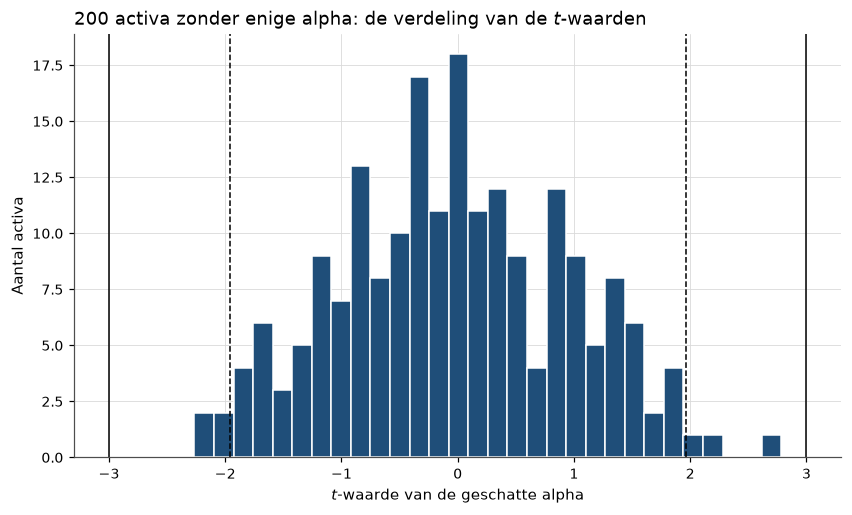

In [5]:
fig, ax = plt.subplots()
ax.hist(t_stats, bins=30, edgecolor="white")
for c, style in [(1.96, "--"), (3.0, "-")]:
    ax.axvline(c, color="black", ls=style, lw=1)
    ax.axvline(-c, color="black", ls=style, lw=1)
ax.set_xlabel("$t$-waarde van de geschatte alpha")
ax.set_ylabel("Aantal activa")
ax.set_title("200 activa zonder enige alpha: de verdeling van de $t$-waarden")
plt.show()

Rond de 5% van de activa haalt $|t| > 1{,}96$ — precies zoals het hoort onder de
nulhypothese, en precies daarom is die drempel waardeloos zodra iemand 200
kandidaten heeft geprobeerd en er één rapporteert. Houd dit resultaat in het
achterhoofd bij de replicatie hieronder.

```{warning}
Herhaal de simulatie nooit met een andere seed tot het getal er mooier uitziet.
Zet de seed één keer bovenaan, rapporteer wat eruit komt, en bespreek de
steekproefruis in de tekst als het afwijkt van de asymptotische waarde.
```

## Replicatie op echte data

```{admonition} Replicatie
:class: seealso

**Bron.** Auteur(s), *Titel*, Journal jaar {cite}`Lucas1978`.

**Wat.** Tabel 3, kolom 2 (of: figuur 1, bovenpaneel).

**Data hier.** Kenneth French Data Library, maandelijkse marktfactor
1926-07 t/m heden, via `hap.data.french("F-F_Research_Data_Factors")`.

**Verschil met het origineel.** Het paper gebruikt CRSP value-weighted
rendementen met een steekproef die eindigt in 19XX; wij gebruiken de
French-reeks tot heden. De portefeuilleconstructie wijkt af in de
herbalanceringsdatum.

**Verwachte afwijking.** Punt schattingen binnen ongeveer 10% van de
gepubliceerde waarden; $t$-waarden lager omdat onze steekproef korter is /
hoger omdat hij langer is. Het teken en de rangorde van de portefeuilles moeten
identiek zijn — wijkt dát af, dan zit er een fout in de code, niet in de data.
```

De data komen altijd uit `hap.data`; nooit uit een download in de lecture zelf.
Valt de loader weg (`HAP_OFFLINE=1` zonder cache), gebruik dan simulatie en zeg
dat expliciet.

In [6]:
# Voorbeeldberekening op gesimuleerde data (in een echte lecture: hap.data.*).
n_years = 100
returns = pd.Series(
    rng.normal(0.08, 0.20, n_years),
    index=pd.period_range("1926", periods=n_years, freq="Y"),
    name="market",
)

summary = pd.DataFrame(
    {
        "gemiddelde": [returns.mean()],
        "std.dev.": [returns.std(ddof=1)],
        "SE gemiddelde": [returns.std(ddof=1) / np.sqrt(n_years)],
        "t-waarde": [returns.mean() / (returns.std(ddof=1) / np.sqrt(n_years))],
    },
    index=["marktrendement"],
).round(4)

summary

,gemiddelde,std.dev.,SE gemiddelde,t-waarde
marktrendement,0.0904,0.1755,0.0175,5.1486


Elke figuur krijgt een titel en aslabels in het Nederlands.

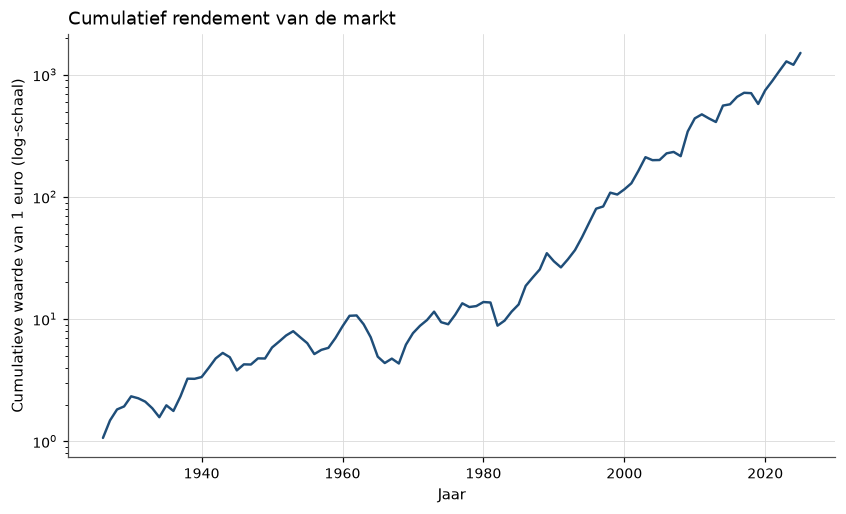

In [7]:
fig, ax = plt.subplots()
ax.plot(returns.index.year, (1 + returns).cumprod(), lw=1.6)
ax.set_yscale("log")
ax.set_xlabel("Jaar")
ax.set_ylabel("Cumulatieve waarde van 1 euro (log-schaal)")
ax.set_title("Cumulatief rendement van de markt")
plt.show()

Een figuur die als bestand op schijf staat (of die je in een aparte cel opslaat)
krijgt een caption en een label, zodat je er in de tekst naar kunt verwijzen:

:::{figure} #fig-template-cumulatief
:label: fig-template-cumulatief
:width: 90%

Cumulatieve waarde van één euro, belegd in de markt. De log-schaal maakt gelijke
procentuele bewegingen even groot; op een lineaire schaal ziet de recente
periode er misleidend dramatisch uit.
:::

## Wat er brak, en wat daarna kwam

Twee tot vier alinea's. Benoem expliciet:

1. **Wat het model verklaart.** Wees genereus — het model heeft niet voor niets
   een tijdvak gedomineerd.
2. **Waar het breekt.** Eén concreet, meetbaar feit dat het model niet aankan.
   Liefst het feit dat je hierboven zelf hebt gerepliceerd.
3. **Risico of vergissing?** Geef beide lezingen: de Chicago-lezing (de
   discontovoet varieert) en de Yale-lezing (de prijs zit ernaast). Kies niet
   voor de lezer.
4. **Wat er daarna kwam.** Eén zin die de volgende lecture aankondigt, met een
   cross-ref: zie [](#template).

## Oefeningen

:::{exercise}
:label: ex-template-1

**Titel van de oefening.** Formuleer de opgave op problem-set-niveau: een
concrete vraag met een numeriek of analytisch antwoord.

1. Leid af dat $R^{f} = 1/\E[m]$ uit [](#eq-template-euler).
2. Simuleer 10 000 steekproeven van 100 jaarlijkse rendementen met
   $\mu = 8\%$ en $\sigma = 20\%$. Welke fractie van de steekproeven geeft een
   gemiddeld rendement dat meer dan 4 procentpunt naast de waarheid ligt?
3. Herhaal (2) voor de standaarddeviatie. Vergelijk.
:::

:::{solution} ex-template-1
:class: dropdown

**(1)** Neem $x_{t+1} = 1$ (een risicovrije claim met payoff 1). Dan geeft
[](#eq-template-euler) $p_t = \E_t[m_{t+1}]$, en $R^{f}_{t+1} = 1/p_t = 1/\E_t[m_{t+1}]$.

**(2) en (3)**

In [8]:
n_sim, n_obs, mu, sigma = 10_000, 100, 0.08, 0.20
sims = rng.normal(mu, sigma, size=(n_sim, n_obs))

frac_mu = np.mean(np.abs(sims.mean(axis=1) - mu) > 0.04)
frac_sd = np.mean(np.abs(sims.std(axis=1, ddof=1) - sigma) > 0.04)

print(f"Gemiddelde meer dan 4pp ernaast : {frac_mu:.1%}")
print(f"Std.dev. meer dan 4pp ernaast   : {frac_sd:.1%}")

Gemiddelde meer dan 4pp ernaast : 4.4%
Std.dev. meer dan 4pp ernaast   : 0.5%


Vier procentpunt is precies twee standaardfouten van het gemiddelde
($\sigma/\sqrt{T} = 20/\sqrt{100} = 2$), dus ongeveer 4,5% van de steekproeven
valt erbuiten. Voor de standaarddeviatie is de standaardfout
$\sigma/\sqrt{2T} \approx 1{,}4$ procentpunt, dus vier procentpunt is bijna drie
standaardfouten en valt in ongeveer 0,5% van de gevallen.

Dat verschil in $t$-eenheden is nog niet eens het echte punt. Het echte punt is
de schaal: vier procentpunt naast een gemiddelde van 8% is een fout van *de
helft* — het verschil tussen een aandelenmarkt die de moeite waard is en een die
dat niet is. Vier procentpunt naast een volatiliteit van 20% is een fout van een
vijfde, en verandert geen enkele conclusie. Zo ziet het 2%-motief eruit in één
simulatie.
:::

:::{exercise}
:label: ex-template-2

**Tweede oefening.** Bij voorkeur een replicatie-uitbreiding: herhaal het
resultaat uit de vorige sectie op een andere steekproefperiode, een andere
sortering, of met een robuuste standaardfout, en interpreteer het verschil.
:::

:::{solution} ex-template-2
:class: dropdown

Uitwerking met code en interpretatie. Sluit af met één zin die zegt wat de
oefening over het hoofdargument leert.
:::

<!-- Referenties: MyST plaatst de lijst met geciteerde bronnen automatisch
     onderaan de pagina (kopje "References"). Voeg GEEN eigen `## Referenties`-
     kop en GEEN `{bibliography}`-directive toe — dat geeft een dubbele lijst.
     Citeer in de tekst met {cite}`Key` of [@Key]; de key moet in
     references.bib staan. -->